#### E-Commerce Dataset with its Business problems.

- I analyzed an e-commerce dataset to find key business problems and explained the real reasons behind them

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading dataset
df=pd.read_csv("Advanced E-Commerce Dataset for SQL, Python or Power BI Projects.csv")

### Exploritory Data Analysis

In [3]:
df.head()

,Order_ID,Order_Date,Region,Product_Category,Marketing_Spend,Website_Visits,Orders,Revenue,Return_Rate,Delivery_Days,Customer_Rating,Payment_Mode,Discount_Percent,Shipping_Cost,Customer_Segment,Repeat_Customer
0,ORD10001,14-01-2025,West,Shoes,6091,8764,394,739932,14.0,7,3.2,Net Banking,17,217,Regular,No
1,ORD10002,29-03-2025,North,Watches,3881,16190,265,857805,2.7,2,4.6,UPI,12,121,Regular,Yes
2,ORD10003,23-01-2025,East,Shoes,3792,18993,294,590352,7.5,1,4.3,UPI,33,91,Budget,Yes
3,ORD10004,06-02-2025,South,Shoes,8732,14055,326,904976,11.1,6,2.6,UPI,13,200,Regular,No
4,ORD10005,29-03-2025,East,Watches,2551,13524,408,1377000,3.7,3,4.9,Debit Card,25,211,Budget,Yes


In [4]:
# DataFrame info. checking
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Order_Date        10000 non-null  object 
 2   Region            10000 non-null  object 
 3   Product_Category  10000 non-null  object 
 4   Marketing_Spend   10000 non-null  int64  
 5   Website_Visits    10000 non-null  int64  
 6   Orders            10000 non-null  int64  
 7   Revenue           10000 non-null  int64  
 8   Return_Rate       10000 non-null  float64
 9   Delivery_Days     10000 non-null  int64  
 10  Customer_Rating   10000 non-null  float64
 11  Payment_Mode      10000 non-null  object 
 12  Discount_Percent  10000 non-null  int64  
 13  Shipping_Cost     10000 non-null  int64  
 14  Customer_Segment  10000 non-null  object 
 15  Repeat_Customer   10000 non-null  object 
dtypes: float64(2), int64(7), object(7)
memory

In [5]:
# Fixed order_date format.
df["Order_Date"]=pd.to_datetime(df["Order_Date"],errors="coerce")

In [6]:
#modifying revenue column name and value in million
df['Revenue_in_million']=df['Revenue']/1000000

In [7]:
# Numerical columns stats
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,10000,2025-03-31 09:26:12.480000,2025-01-01 00:00:00,2025-02-14 00:00:00,2025-03-31 00:00:00,2025-05-15 00:00:00,2025-06-30 00:00:00,NaN
Marketing_Spend,10000.0,5625.1509,2501.0,4224.0,5542.0,7006.25,9000.0,1763.301187
Website_Visits,10000.0,13534.8881,7000.0,10334.75,13518.0,16790.0,19999.0,3746.480652
Orders,10000.0,292.3328,120.0,228.0,291.0,358.0,420.0,74.418431
Revenue,10000.0,768487.5505,187206.0,580715.25,747283.5,945630.0,1465662.0,254794.280459
Return_Rate,10000.0,8.62738,1.0,5.0,7.9,12.2,21.9,4.127491
Delivery_Days,10000.0,4.2189,1.0,2.0,4.0,6.0,8.0,2.178361
Customer_Rating,10000.0,4.05736,2.1,3.6,4.1,4.5,5.0,0.569096
Discount_Percent,10000.0,20.1021,5.0,12.0,20.0,28.0,35.0,8.97729
Shipping_Cost,10000.0,165.1116,80.0,122.0,165.0,208.0,250.0,49.551207


In [8]:
## Categorical column stats
df.describe(include="object").T

,count,unique,top,freq
Order_ID,10000,10000,ORD10001,1
Region,10000,4,East,2553
Product_Category,10000,5,Electronics,2031
Payment_Mode,10000,5,COD,2031
Customer_Segment,10000,3,Regular,3350
Repeat_Customer,10000,2,No,5111


##### Here is the business problem, based on this i'll be exploring the data and giving solution to the Stakeholder
1. Which region and product category is underperforming the most and why?
2. Is higher marketing spend actually improving orders and revenue?
3. Which regions are getting high website traffic but poor conversion rates?
4. Which customer segment is most valuable for the business?
5. Are discounts helping sales growth or hurting overall revenue quality?
6. Which operational issue is impacting customer experience the most?
7. Which KPI should leadership monitor most closely to improve business growth?
8. What strategic recommendations would you give to improve revenue, customer satisfaction, and operational efficiency?

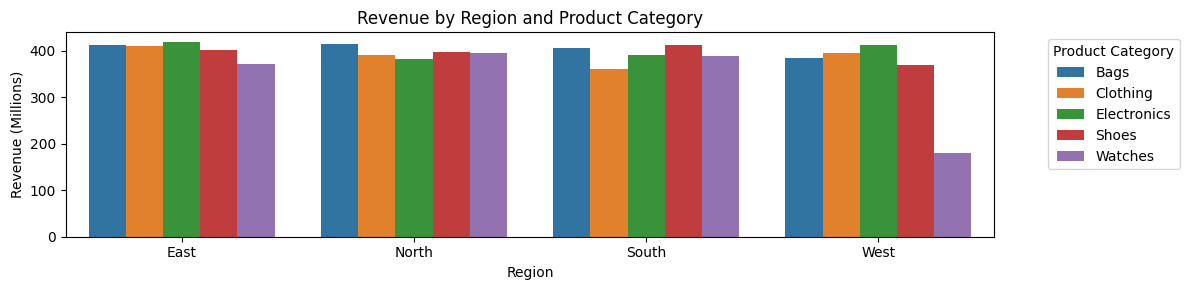

In [9]:
# 1. Which region and product category is underperforming the most and why?

revenue_by_region=df.pivot_table(index=['Region','Product_Category'],values='Revenue_in_million',aggfunc='sum')
plt.figure(figsize=(12, 3))
sns.barplot(data=revenue_by_region, x='Region', y='Revenue_in_million', hue='Product_Category')

plt.title('Revenue by Region and Product Category')
plt.ylabel('Revenue (Millions)')
plt.xlabel('Region')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
df.groupby(['Region','Product_Category'])[['Delivery_Days','Customer_Rating','Return_Rate']].mean().tail()

Delivery_Days  Customer_Rating  Return_Rate
Region Product_Category                                             
West   Bags                   6.016360         3.592025    11.939264
       Clothing               5.952286         3.587873    12.031213
       Electronics            5.998066         3.639458    12.173888
       Shoes                  5.958785         3.596312    12.036659
       Watches                6.080614         3.594050    15.205950

Region wise Delivery days, customer rating and return rate, I found that the Watches category in the West region is underperforming. One major reason appears to be operational inefficiency, as the average delivery time is around 6 days. Due to delayed deliveries, customer satisfaction is getting impacted, which is reflected in the low average customer rating below 3.6. This poor customer experience may also be contributing to lower conversions and higher return rates (15%) in the West region.

In [11]:
# Relation between delivery date and return rate
corr_rel = df['Delivery_Days'].corr(df['Return_Rate'])
corr_rel

np.float64(0.7158438472308)

- The positive correlation (0.71) tells that as delivery days increase, Return_rate increases too.

In [12]:
# 2. Is higher marketing spend actually improving orders and revenue?
m_spend_vs_orders_corr = df['Marketing_Spend'].corr(df['Orders'])
print(m_spend_vs_orders_corr)

m_spend_vs_revenue_corr = df['Marketing_Spend'].corr(df['Revenue'])
print(m_spend_vs_revenue_corr)

-0.06210555017367641
-0.06859522140537115


- The analysis indicates that higher marketing spend is not significantly contributing to higher orders or revenue.
- The correlation tells that there is no relation between them.

In [13]:
#3. Which regions are getting high website traffic but poor conversion rates?

# conversion rate = (orders/website_visits)*100
df['conversion_rate']= (df['Orders']/df['Website_Visits'])*100
df.groupby(["Region"])[['Website_Visits','conversion_rate']].sum()


,Website_Visits,conversion_rate
Region,,
East,34487630,6136.647677
North,33800529,6012.425823
South,33294695,5954.077190
West,33766027,5442.179148


- South and West regions are receiving high website traffic but showing lower conversion rates, indicating that customer acquisition exists but purchase conversion is weak. Operational issues such as delayed deliveries and lower customer ratings may be impacting customer decision-making.

In [55]:
## 4. Which customer segment is most valuable for the business?
cus_segment_wise_rev = df.groupby(df['Customer_Segment'])['Revenue_in_million'].sum().reset_index().sort_values(by='Revenue_in_million',ascending=False)
cus_segment_wise_rev

,Customer_Segment,Revenue_in_million
0,Budget,2583.307641
1,Premium,2566.667197
2,Regular,2534.900667


- The Budget customer segment appears to be the most valuable for the business because it contributes the highest overall orders/revenue compared to other segments. This suggests that the company’s products and pricing strategy are currently attracting price-sensitive customers more effectively than Premium or Regular segments.

In [ ]:
# 5. Are discounts helping sales growth or hurting overall revenue quality?
dis_and_rev_corr = df["Discount_Percent"].corr(df['Revenue_in_million'])
print(dis_and_rev_corr)

0.008119531386900835


- The analysis shows almost no significant relationship between Discount Percentage and Revenue, suggesting that higher discounts are not meaningfully improving revenue growth.

In [ ]:
# 6. Which operational issue is impacting customer experience the most?
print(df["Delivery_Days"].corr(df['Return_Rate']))
print(df["Delivery_Days"].corr(df['conversion_rate']))

0.7158438472308
-0.04604011781923466


- The analysis suggests that Delayed order delivery is impacting customers experience the most,
- As Delivery days get increase Return rate increases too.
- As delivery days get decrease Conversion rate increases too.
- customers are more likely to complete purchases when delivery performance is faster.

##### 7. Which KPI should leadership monitor most closely to improve business growth?
- Customer Ratings
- Return Rates
- Conversion Rates
- Customer Experience
- Overall Business Performance

##### 8. recommendations 
> The company should primarily focus on improving delivery efficiency, especially in underperforming regions like West and South, as delayed deliveries are negatively impacting customer ratings, conversion rates, and return behavior.

> The business should optimize operational processes such as warehouse management, inventory allocation, and shipping logistics to reduce average delivery time.

> Marketing spend should be optimized rather than increased blindly, since the analysis suggests that higher marketing investment is not significantly improving orders or revenue.

> The company should also investigate high-return categories and regions to identify root causes such as delayed delivery, customer dissatisfaction, or product expectation mismatch.

> Improving customer experience through faster deliveries and better service quality could help increase customer trust, improve conversion rates, reduce returns, and ultimately drive long-term revenue growth.
